# Disease Outbreak Early Warning System

## Notebook 05: Outbreak Detection and Early Warning Alerts

### Purpose

Forecasting disease incidence is only valuable if it can be translated into actionable public health insights.

This notebook develops an outbreak detection framework that identifies unusual increases in disease activity and generates risk-based early warning alerts.

### Objectives

- Define outbreak thresholds
- Detect abnormal disease activity
- Create risk categories
- Generate warning alerts
- Support public health decision making

### Expected Outcome

An automated early warning system capable of classifying future disease risk and identifying potential outbreak periods.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs("images", exist_ok=True)

print("Libraries loaded successfully.")

Libraries loaded successfully.


## Loading the Dengue Dataset

The historical dengue surveillance data are loaded and aggregated into a weekly disease incidence series.

In [ ]:
features = pd.read_csv(
    "/content/dengue_features_train.csv"
)

labels = pd.read_csv(
    "/content/dengue_labels_train.csv"
)

dengue_df = pd.merge(
    features,
    labels,
    on=[
        "city",
        "year",
        "weekofyear"
    ]
)

dengue_df["week_start_date"] = pd.to_datetime(
    dengue_df["week_start_date"]
)

time_series = (
    dengue_df
    .groupby("week_start_date")
    ["total_cases"]
    .sum()
)

time_series.head()

,total_cases
week_start_date,
1990-04-30,4
1990-05-07,5
1990-05-14,4
1990-05-21,3
1990-05-28,6


## Defining Outbreak Thresholds

A simple statistical outbreak detection rule is applied.

Values exceeding the historical mean plus one standard deviation are classified as elevated disease activity.

In [ ]:
mean_cases = time_series.mean()

std_cases = time_series.std()

outbreak_threshold = (
    mean_cases + std_cases
)

print(
    "Mean Cases:",
    round(mean_cases,2)
)

print(
    "Standard Deviation:",
    round(std_cases,2)
)

print(
    "Outbreak Threshold:",
    round(outbreak_threshold,2)
)

Mean Cases: 34.25
Standard Deviation: 48.87
Outbreak Threshold: 83.12


## Detecting Historical Outbreak Periods

Weeks exceeding the outbreak threshold are flagged as potential outbreak events.

In [ ]:
outbreaks = (
    time_series >
    outbreak_threshold
)

outbreak_df = pd.DataFrame({
    "cases": time_series,
    "outbreak_flag": outbreaks
})

outbreak_df.head()

,cases,outbreak_flag
week_start_date,,
1990-04-30,4,False
1990-05-07,5,False
1990-05-14,4,False
1990-05-21,3,False
1990-05-28,6,False


In [ ]:
print(
    "Number of Outbreak Weeks:",
    outbreak_df["outbreak_flag"].sum()
)

Number of Outbreak Weeks: 72


## Historical Outbreak Visualization

Potential outbreak periods are highlighted relative to the threshold level.

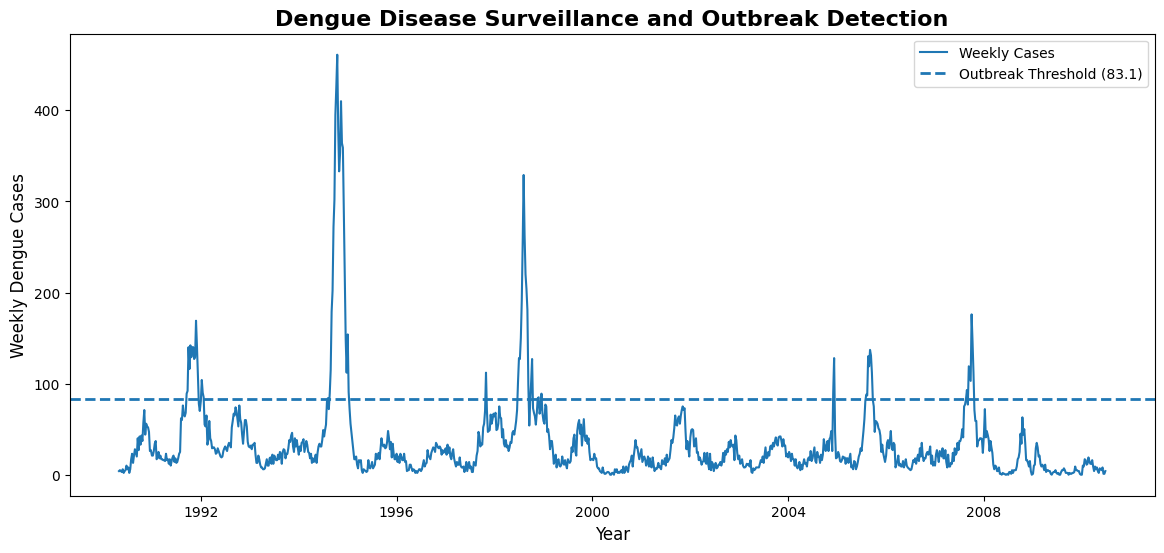

In [ ]:
plt.figure(figsize=(14,6))

plt.plot(
    time_series,
    linewidth=1.5,
    label="Weekly Cases"
)

plt.axhline(
    outbreak_threshold,
    linestyle="--",
    linewidth=2,
    label=f"Outbreak Threshold ({outbreak_threshold:.1f})"
)

plt.title(
    "Dengue Disease Surveillance and Outbreak Detection",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel(
    "Year",
    fontsize=12
)

plt.ylabel(
    "Weekly Dengue Cases",
    fontsize=12
)

plt.legend()

plt.savefig(
    "images/project_banner.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    "images/historical_outbreak_detection.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Risk Classification Framework

Disease activity is categorized into three operational risk levels:

- Low Risk
- Moderate Risk
- High Risk

These categories support rapid interpretation by decision makers.

In [ ]:
def classify_risk(x):

    if x < mean_cases:
        return "Low Risk"

    elif x < outbreak_threshold:
        return "Moderate Risk"

    else:
        return "High Risk"

In [ ]:
outbreak_df["risk_level"] = (
    outbreak_df["cases"]
    .apply(classify_risk)
)

outbreak_df.head()

,cases,outbreak_flag,risk_level
week_start_date,,,
1990-04-30,4,False,Low Risk
1990-05-07,5,False,Low Risk
1990-05-14,4,False,Low Risk
1990-05-21,3,False,Low Risk
1990-05-28,6,False,Low Risk


In [ ]:
outbreak_df["risk_level"].value_counts()

,count
risk_level,
Low Risk,748
Moderate Risk,229
High Risk,72


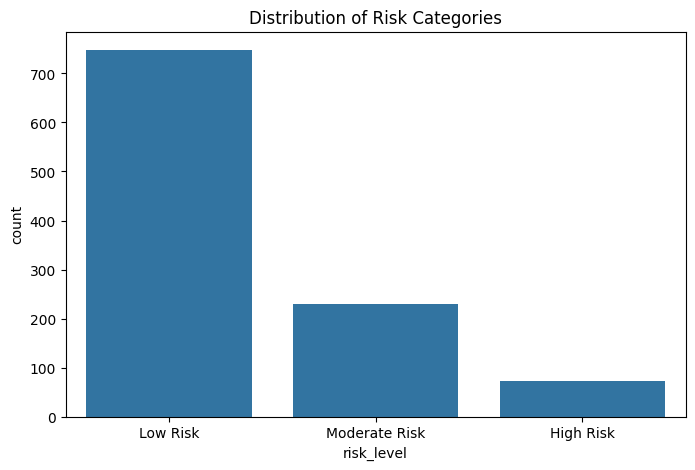

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=outbreak_df,
    x="risk_level"
)

plt.title(
    "Distribution of Risk Categories"
)

plt.savefig(
    "images/risk_category_distribution.png",
    bbox_inches="tight"
)

plt.show()

## Early Warning Alert Generation

The system generates warning alerts whenever disease activity exceeds the predefined outbreak threshold.

In [ ]:
alerts = outbreak_df[
    outbreak_df["risk_level"]
    == "High Risk"
]

alerts.head(10)

,cases,outbreak_flag,risk_level
week_start_date,,,
1991-09-17,89,True,High Risk
1991-09-24,92,True,High Risk
1991-10-01,140,True,High Risk
1991-10-08,116,True,High Risk
1991-10-15,142,True,High Risk
1991-10-22,129,True,High Risk
1991-10-29,140,True,High Risk
1991-11-05,140,True,High Risk
1991-11-12,127,True,High Risk


In [ ]:
print(
    "Total High-Risk Alerts:",
    len(alerts)
)

Total High-Risk Alerts: 72


In [ ]:
risk_summary = (
    outbreak_df["risk_level"]
    .value_counts()
    .reset_index()
)

risk_summary.columns = [
    "Risk Level",
    "Count"
]

risk_summary

,Risk Level,Count
0,Low Risk,748
1,Moderate Risk,229
2,High Risk,72


In [ ]:
risk_summary.to_csv(
    "risk_summary.csv",
    index=False
)

print(
    "Risk summary saved."
)

Risk summary saved.


## Risk Category Distribution

| Risk Level | Count |
|------------|--------|
| Low Risk | 748 |
| Moderate Risk | 229 |
| High Risk | 72 |

Total observations: 1049

High-risk alerts: 72

Percentage of high-risk periods:

72 / 1049 × 100 = 6.86%

In [ ]:
alerts.to_csv(
    "high_risk_alerts.csv",
    index=True
)

print(
    "Alert file created successfully."
)

Alert file created successfully.


## Interpretation of Early Warning Results

The outbreak detection framework classified historical disease activity into three operational risk levels.

The majority of observations were categorized as Low Risk, indicating relatively stable disease activity during most surveillance periods.

A smaller proportion of observations were classified as Moderate Risk, while 72 weeks were identified as High Risk and generated outbreak alerts.

Approximately 6.9% of all observed weeks exceeded the outbreak threshold, suggesting that significant outbreak activity occurred infrequently but was detectable using the proposed statistical framework.

These results demonstrate the potential of simple threshold-based surveillance systems for identifying periods requiring increased public health attention.

In [ ]:
import os

print(
    os.listdir("images")
)

['historical_outbreak_detection.png', 'risk_category_distribution.png']
